XGBOOST ORDINAL CLASSIFICATION MODEL
Sleep Patterns & Academic Performance (CGPA3_Class)

📁 Upload your CSV file (Raw.csv)


Saving Raw.csv to Raw (3).csv

✓ Dataset: 1481 students, 34 features
✓ Target: CGPA3_Class (0=High, 1=Medium, 2=Low)

Class Distribution:
   Class 0:  655 ( 44.2%)
   Class 1:  608 ( 41.1%)
   Class 2:  218 ( 14.7%)

✓ Selected 8 high-value features
✓ Clean dataset: 1481 students

FEATURE ENGINEERING: Creating 7 Engineered Features
✓ Sleep_Quality_Score = AVG_Sleep_Per_Night × Rate_Sleep_Quality
✓ Sleep_Deficit = max(0, 7 - AVG_Sleep_Per_Night)
✓ Bedtime_Consistency = |Regular_Bed_time - Holiday_Bed_Time|
✓ Exam_Sleep_Disruption = |Regular_Bed_time - Exam_Night_Bed_Time|
✓ Sleep_Disruption_Index = Sum of 3 disruption factors
✓ Academic_Engagement_Score = Mean(Class_Attendance, Focus_on_Academic_Task)
✓ Sleep_Hygiene_Score = Mean(Have_Regular_Bed_Time, 1-Electronics, 1-Caffeine)

✓ Selected 8 high-value features
Selected Features:
  1. Sleepiness_During_Class
  2. Impact_of_Sleep_on_Academic
  3. Focus_on_Academic_Task
  4. AVG_Sleep_Per_Night
  5. Struggle_to_Sleep
  6. Daily_Academics

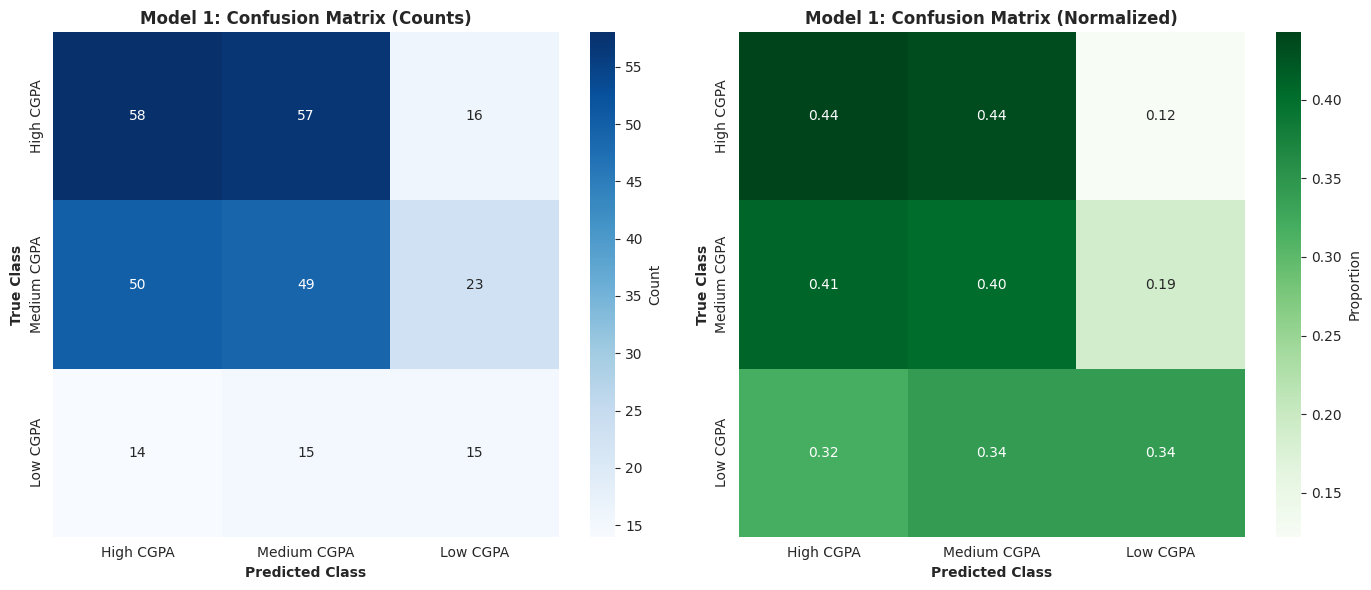


MODEL 2: XGBoost with Raw + Engineered Features (15 Total)

📊 MODEL 2 RESULTS:
   Accuracy:          0.4411
   Balanced Accuracy: 0.4197
   Macro F1-Score:    0.4215
   Mean Abs Error:    0.6431
   ROC-AUC (Macro):   0.5880

📋 Classification Report:
              precision    recall  f1-score   support

   High CGPA     0.4793    0.4427    0.4603       131
 Medium CGPA     0.4296    0.4754    0.4514       122
    Low CGPA     0.3659    0.3409    0.3529        44

    accuracy                         0.4411       297
   macro avg     0.4249    0.4197    0.4215       297
weighted avg     0.4421    0.4411    0.4407       297



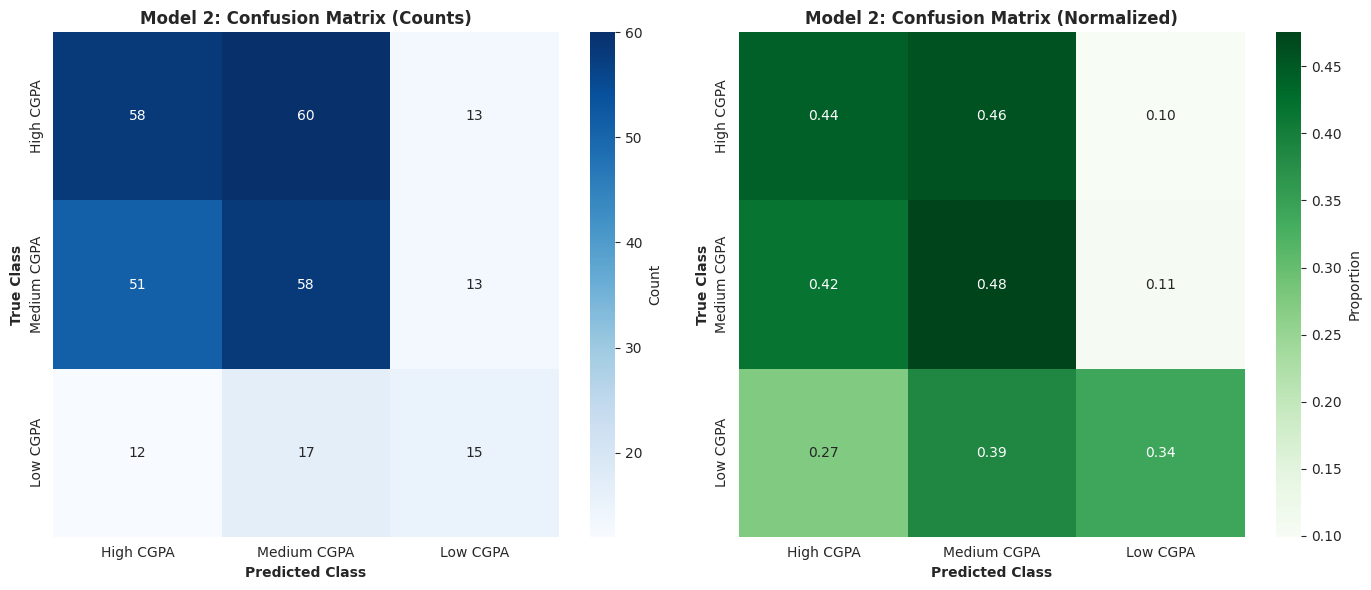


ROC-AUC CURVE COMPARISON


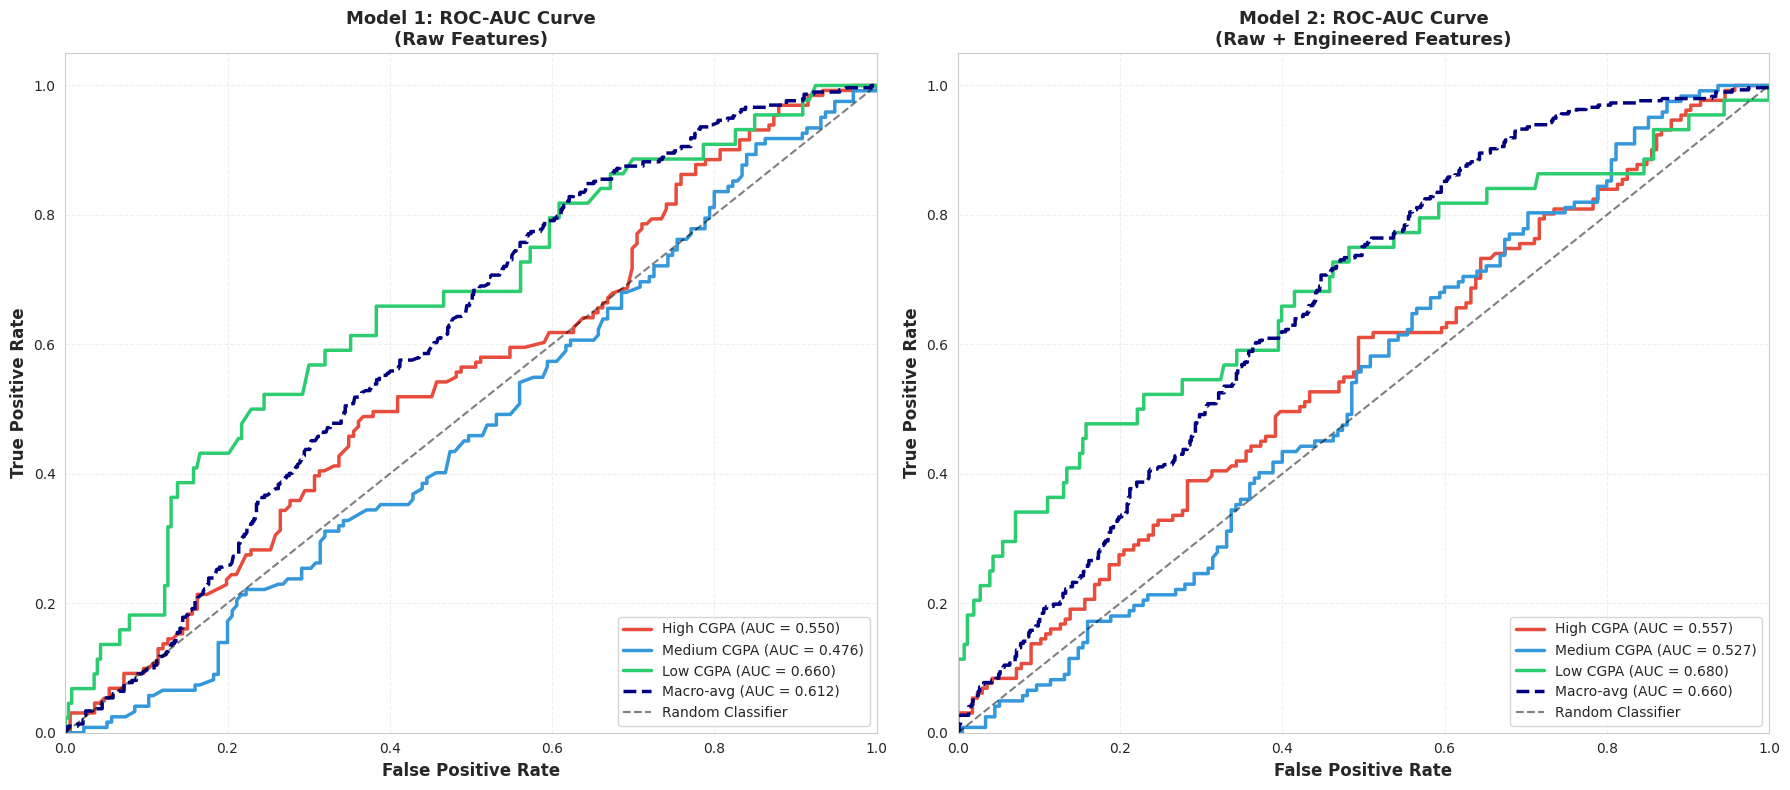


📊 ROC-AUC Summary:
   Model 1 (Raw):        Macro AUC = 0.6122
   Model 2 (Raw+Eng):    Macro AUC = 0.6601
   Improvement:          +0.0479

FEATURE IMPORTANCE ANALYSIS (Model 2)

📊 Top 15 Most Important Features:
 1. 📌 Sleepiness_During_Class                 : 0.0987
 2. 📌 Focus_on_Academic_Task                  : 0.0851
 3. 🔧 Sleep_Disruption_Index                  : 0.0823
 4. 🔧 Sleep_Hygiene_Score                     : 0.0765
 5. 🔧 Academic_Engagement_Score               : 0.0729
 6. 📌 Struggle_to_Sleep                       : 0.0706
 7. 🔧 Sleep_Deficit                           : 0.0627
 8. 📌 Impact_of_Sleep_on_Academic             : 0.0623
 9. 🔧 Sleep_Quality_Score                     : 0.0620
10. 📌 Daily_Academics_Time_Spend              : 0.0591
11. 🔧 Bedtime_Consistency                     : 0.0576
12. 📌 AVG_Sleep_Per_Night                     : 0.0563
13. 📌 Skip_Class_for_Sleep                    : 0.0537
14. 🔧 Exam_Sleep_Disruption                   : 0.0517
15. 📌 Sacrifice

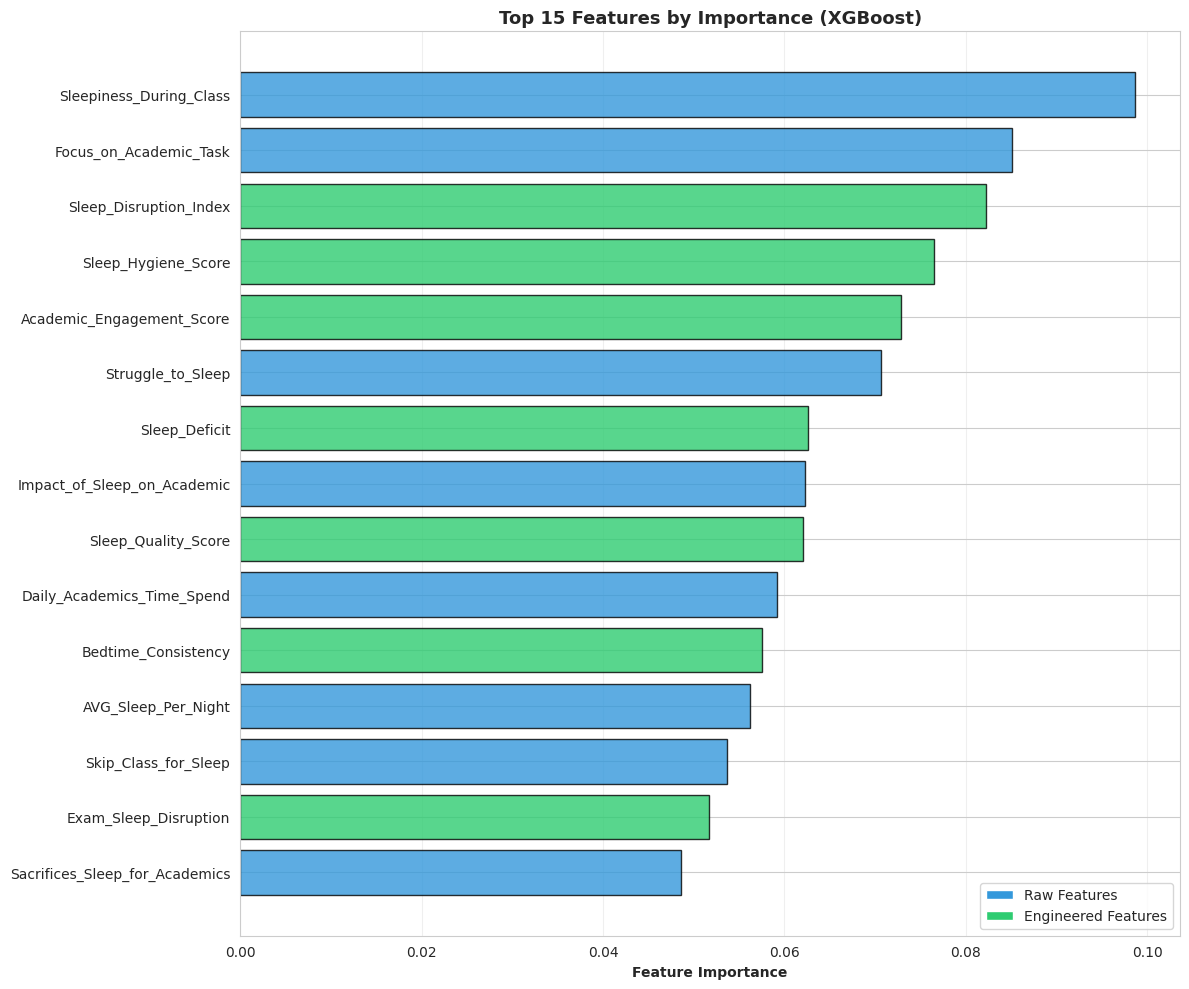


FINAL MODEL COMPARISON

      Metric  Model 1 (Raw)  Model 2 (Raw+Eng)
    Accuracy       0.410774           0.441077
Balanced Acc       0.395099           0.419689
    Macro F1       0.389304           0.421540
         MAE       0.690236           0.643098
   Macro AUC       0.612194           0.660114


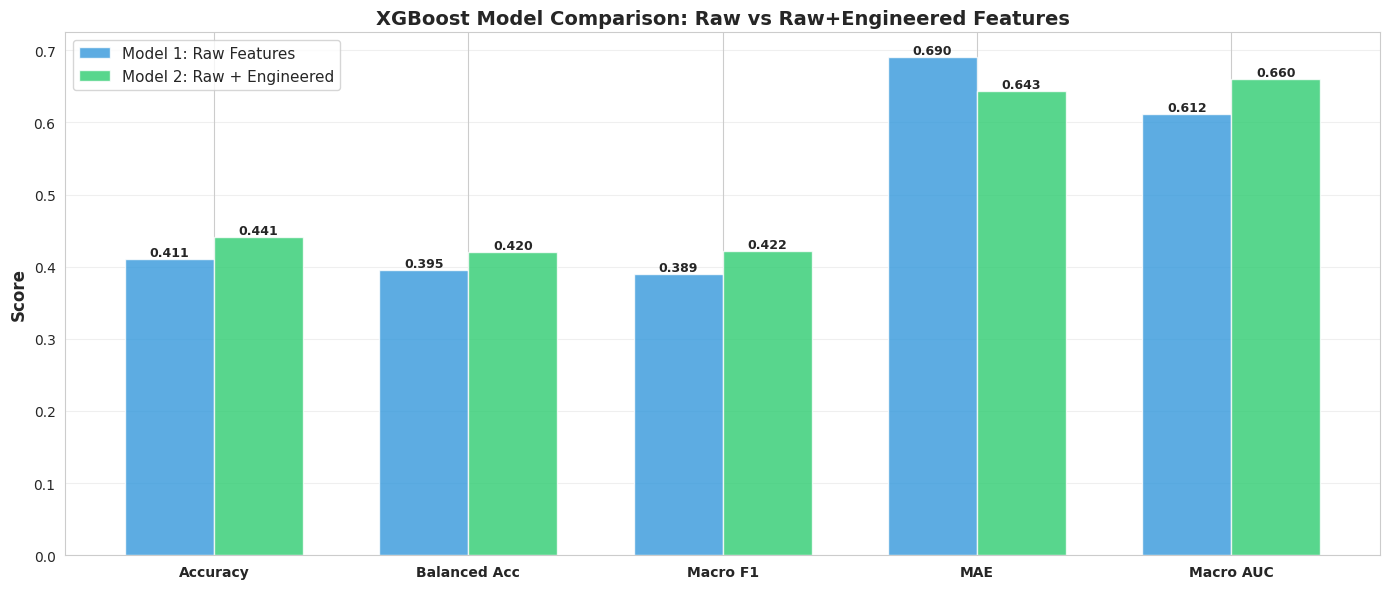


ANALYSIS COMPLETE

✅ XGBOOST ORDINAL CLASSIFICATION RESULTS

📊 MODEL 1 (Raw Features - 8 High-Value):
   • Accuracy:          0.4108
   • Balanced Accuracy: 0.3951
   • Macro F1-Score:    0.3893
   • Mean Abs Error:    0.6902
   • Macro AUC:         0.6122

📊 MODEL 2 (Raw + Engineered - 15 Total):
   • Accuracy:          0.4411
   • Balanced Accuracy: 0.4197
   • Macro F1-Score:    0.4215
   • Mean Abs Error:    0.6431
   • Macro AUC:         0.6601

📈 IMPROVEMENT: +0.0303 accuracy gain
                +0.0246 balanced accuracy gain

🎯 Best Model: Model 2 (Raw + Engineered)



In [ ]:
# ============================================================================
# XGBoost Ordinal Classification: Sleep & Academic Performance
# Professional Implementation with Feature Engineering
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix,
                             mean_absolute_error, roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

# Install required packages
!pip install xgboost imbalanced-learn -q

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("=" * 80)
print("XGBOOST ORDINAL CLASSIFICATION MODEL")
print("Sleep Patterns & Academic Performance (CGPA3_Class)")
print("=" * 80)

# ============================================================================
# 1. DATA LOADING
# ============================================================================

from google.colab import files
print("\n📁 Upload your CSV file (Raw.csv)")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f"\n✓ Dataset: {df.shape[0]} students, {df.shape[1]} features")
print(f"✓ Target: CGPA3_Class (0=High, 1=Medium, 2=Low)")
print(f"\nClass Distribution:")
for i in range(3):
    count = (df['CGPA3_Class'] == i).sum()
    print(f"   Class {i}: {count:4d} ({count/len(df)*100:5.1f}%)")

# ============================================================================
# 2. FEATURE SELECTION (8 High-Value Features)
# ============================================================================

high_value_features = [
    'Sleepiness_During_Class',
    'Impact_of_Sleep_on_Academic',
    'Focus_on_Academic_Task',
    'AVG_Sleep_Per_Night',
    'Struggle_to_Sleep',
    'Daily_Academics_Time_Spend',
    'Skip_Class_for_Sleep',
    'Sacrifices_Sleep_for_Academics'
]

# Verify all features exist
available_features = [f for f in high_value_features if f in df.columns]
if len(available_features) < len(high_value_features):
    missing = set(high_value_features) - set(available_features)
    print(f"\n⚠️  Missing features: {missing}")
    high_value_features = available_features

print(f"\n✓ Selected {len(high_value_features)} high-value features")

# Handle missing values
df = df.dropna(subset=high_value_features + ['CGPA3_Class'])
print(f"✓ Clean dataset: {df.shape[0]} students")

# ============================================================================
# 3. FEATURE ENGINEERING (7 Engineered Features)
# ============================================================================

print("\n" + "=" * 80)
print("FEATURE ENGINEERING: Creating 7 Engineered Features")
print("=" * 80)

def z_score_normalize(series):
    return (series - series.mean()) / series.std()

# Feature 1: Sleep_Quality_Score
if 'Rate_Sleep_Quality' in df.columns:
    df['Sleep_Quality_Score'] = df['AVG_Sleep_Per_Night'] * df['Rate_Sleep_Quality']
else:
    df['Sleep_Quality_Score'] = df['AVG_Sleep_Per_Night']
print("✓ Sleep_Quality_Score = AVG_Sleep_Per_Night × Rate_Sleep_Quality")

# Feature 2: Sleep_Deficit
df['Sleep_Deficit'] = (7 - df['AVG_Sleep_Per_Night']).clip(lower=0)
print("✓ Sleep_Deficit = max(0, 7 - AVG_Sleep_Per_Night)")

# Feature 3: Bedtime_Consistency
if 'Regular_Bed_time' in df.columns and 'Holiday_Bed_Time' in df.columns:
    df['Bedtime_Consistency'] = abs(df['Regular_Bed_time'] - df['Holiday_Bed_Time'])
    print("✓ Bedtime_Consistency = |Regular_Bed_time - Holiday_Bed_Time|")
else:
    df['Bedtime_Consistency'] = 0

# Feature 4: Exam_Sleep_Disruption
if 'Regular_Bed_time' in df.columns and 'Exam_Night_Bed_Time' in df.columns:
    df['Exam_Sleep_Disruption'] = abs(df['Regular_Bed_time'] - df['Exam_Night_Bed_Time'])
    print("✓ Exam_Sleep_Disruption = |Regular_Bed_time - Exam_Night_Bed_Time|")
else:
    df['Exam_Sleep_Disruption'] = 0

# Feature 5: Sleep_Disruption_Index
disruption_cols = ['Struggle_to_Sleep', 'Sleepiness_During_Class', 'Skip_Class_for_Sleep']
disruption_available = [c for c in disruption_cols if c in df.columns]
if len(disruption_available) >= 2:
    disruption_df = df[disruption_available].copy()
    df['Sleep_Disruption_Index'] = disruption_df.mean(axis=1)
    print(f"✓ Sleep_Disruption_Index = Sum of {len(disruption_available)} disruption factors")
else:
    df['Sleep_Disruption_Index'] = 0

# Feature 6: Academic_Engagement_Score
if 'Class_Attendance' in df.columns:
    df['Academic_Engagement_Score'] = df[['Class_Attendance', 'Focus_on_Academic_Task']].mean(axis=1)
    print("✓ Academic_Engagement_Score = Mean(Class_Attendance, Focus_on_Academic_Task)")
else:
    df['Academic_Engagement_Score'] = df['Focus_on_Academic_Task']

# Feature 7: Sleep_Hygiene_Score
hygiene_components = []
if 'Have_Regular_Bed_Time' in df.columns:
    hygiene_components.append(df['Have_Regular_Bed_Time'])
if 'Electronic_Devices_Before_Bed' in df.columns:
    hygiene_components.append(1 - df['Electronic_Devices_Before_Bed'])
if 'Consume_Caffeine_Night' in df.columns:
    hygiene_components.append(1 - df['Consume_Caffeine_Night'])

if len(hygiene_components) > 0:
    df['Sleep_Hygiene_Score'] = pd.concat(hygiene_components, axis=1).mean(axis=1)
    print("✓ Sleep_Hygiene_Score = Mean(Have_Regular_Bed_Time, 1-Electronics, 1-Caffeine)")
else:
    df['Sleep_Hygiene_Score'] = 0

engineered_features = [
    'Sleep_Quality_Score',
    'Sleep_Deficit',
    'Bedtime_Consistency',
    'Exam_Sleep_Disruption',
    'Sleep_Disruption_Index',
    'Academic_Engagement_Score',
    'Sleep_Hygiene_Score'
]

# Fill any remaining NaN values in engineered features
for feat in engineered_features:
    if df[feat].isna().any():
        df[feat] = df[feat].fillna(df[feat].median())

print(f"\n✓ Selected 8 high-value features")
print("Selected Features:")
for i, feat in enumerate(high_value_features, 1):
    print(f"  {i}. {feat}")

# ============================================================================
# 4. TRAIN/TEST SPLIT
# ============================================================================

X_raw = df[high_value_features].copy()
X_combined = df[high_value_features + engineered_features].copy()
y = df['CGPA3_Class'].copy()

X_raw_train, X_raw_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

X_comb_train, X_comb_test, _, _ = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✓ Train: {len(y_train)} | Test: {len(y_test)}")

# ============================================================================
# 5. SMOTE FOR CLASS BALANCE
# ============================================================================

print("\n" + "=" * 80)
print("ADDRESSING CLASS IMBALANCE WITH SMOTE")
print("=" * 80)

smote = SMOTE(random_state=42, k_neighbors=5)
X_raw_train_bal, y_train_bal = smote.fit_resample(X_raw_train, y_train)
X_comb_train_bal, _ = smote.fit_resample(X_comb_train, y_train)

print(f"\n✓ Training samples: {len(y_train)} → {len(y_train_bal)}")

# ============================================================================
# 6. FEATURE SCALING
# ============================================================================

scaler_raw = StandardScaler()
scaler_comb = StandardScaler()

X_raw_train_scaled = scaler_raw.fit_transform(X_raw_train_bal)
X_raw_test_scaled = scaler_raw.transform(X_raw_test)

X_comb_train_scaled = scaler_comb.fit_transform(X_comb_train_bal)
X_comb_test_scaled = scaler_comb.transform(X_comb_test)

print("✓ Features standardized (mean=0, std=1)")

# ============================================================================
# 7. MODEL 1: XGBOOST WITH RAW FEATURES
# ============================================================================

print("\n" + "=" * 80)
print("MODEL 1: XGBoost with Raw Features (8 High-Value)")
print("=" * 80)

model_raw = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    max_depth=5,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    tree_method='hist'
)

model_raw.fit(X_raw_train_scaled, y_train_bal)
y_pred_raw = model_raw.predict(X_raw_test_scaled)
y_prob_raw = model_raw.predict_proba(X_raw_test_scaled)

# Metrics
acc_raw = accuracy_score(y_test, y_pred_raw)
bal_acc_raw = balanced_accuracy_score(y_test, y_pred_raw)
f1_raw = f1_score(y_test, y_pred_raw, average='macro')
mae_raw = mean_absolute_error(y_test, y_pred_raw)

# Calculate ROC-AUC
roc_auc_raw_score = roc_auc_score(y_test, y_prob_raw, multi_class='ovr', average='macro')

print(f"\n📊 MODEL 1 RESULTS:")
print(f"   Accuracy:          {acc_raw:.4f}")
print(f"   Balanced Accuracy: {bal_acc_raw:.4f}")
print(f"   Macro F1-Score:    {f1_raw:.4f}")
print(f"   Mean Abs Error:    {mae_raw:.4f}")
print(f"   ROC-AUC (Macro):   {roc_auc_raw_score:.4f}")

# Classification Report
print(f"\n📋 Classification Report:")
labels = ['High CGPA', 'Medium CGPA', 'Low CGPA']
print(classification_report(y_test, y_pred_raw, target_names=labels, digits=4))

# Confusion Matrix
cm_raw = confusion_matrix(y_test, y_pred_raw)
cm_raw_norm = confusion_matrix(y_test, y_pred_raw, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels, cbar_kws={'label': 'Count'})
axes[0].set_title('Model 1: Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Class', fontweight='bold')
axes[0].set_xlabel('Predicted Class', fontweight='bold')

sns.heatmap(cm_raw_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=labels, yticklabels=labels, cbar_kws={'label': 'Proportion'})
axes[1].set_title('Model 1: Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Class', fontweight='bold')
axes[1].set_xlabel('Predicted Class', fontweight='bold')

plt.tight_layout()
plt.show()

# ROC-AUC Curve - Store for later comparison
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

fpr_raw = dict()
tpr_raw = dict()
roc_auc_raw = dict()

for i in range(n_classes):
    fpr_raw[i], tpr_raw[i], _ = roc_curve(y_test_bin[:, i], y_prob_raw[:, i])
    roc_auc_raw[i] = auc(fpr_raw[i], tpr_raw[i])

# Macro-average
fpr_raw["macro"], tpr_raw["macro"], _ = roc_curve(y_test_bin.ravel(), y_prob_raw.ravel())
roc_auc_raw["macro"] = auc(fpr_raw["macro"], tpr_raw["macro"])

# ============================================================================
# 8. MODEL 2: XGBOOST WITH RAW + ENGINEERED FEATURES
# ============================================================================

print("\n" + "=" * 80)
print("MODEL 2: XGBoost with Raw + Engineered Features (15 Total)")
print("=" * 80)

model_comb = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    tree_method='hist'
)

model_comb.fit(X_comb_train_scaled, y_train_bal)
y_pred_comb = model_comb.predict(X_comb_test_scaled)
y_prob_comb = model_comb.predict_proba(X_comb_test_scaled)

# Metrics
acc_comb = accuracy_score(y_test, y_pred_comb)
bal_acc_comb = balanced_accuracy_score(y_test, y_pred_comb)
f1_comb = f1_score(y_test, y_pred_comb, average='macro')
mae_comb = mean_absolute_error(y_test, y_pred_comb)

# Calculate ROC-AUC
roc_auc_comb_score = roc_auc_score(y_test, y_prob_comb, multi_class='ovr', average='macro')

print(f"\n📊 MODEL 2 RESULTS:")
print(f"   Accuracy:          {acc_comb:.4f}")
print(f"   Balanced Accuracy: {bal_acc_comb:.4f}")
print(f"   Macro F1-Score:    {f1_comb:.4f}")
print(f"   Mean Abs Error:    {mae_comb:.4f}")
print(f"   ROC-AUC (Macro):   {roc_auc_comb_score:.4f}")

# Classification Report
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred_comb, target_names=labels, digits=4))

# Confusion Matrix
cm_comb = confusion_matrix(y_test, y_pred_comb)
cm_comb_norm = confusion_matrix(y_test, y_pred_comb, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_comb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels, cbar_kws={'label': 'Count'})
axes[0].set_title('Model 2: Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Class', fontweight='bold')
axes[0].set_xlabel('Predicted Class', fontweight='bold')

sns.heatmap(cm_comb_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=labels, yticklabels=labels, cbar_kws={'label': 'Proportion'})
axes[1].set_title('Model 2: Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Class', fontweight='bold')
axes[1].set_xlabel('Predicted Class', fontweight='bold')

plt.tight_layout()
plt.show()

# ROC-AUC Curve - Store for later comparison
fpr_comb = dict()
tpr_comb = dict()
roc_auc_comb = dict()

for i in range(n_classes):
    fpr_comb[i], tpr_comb[i], _ = roc_curve(y_test_bin[:, i], y_prob_comb[:, i])
    roc_auc_comb[i] = auc(fpr_comb[i], tpr_comb[i])

fpr_comb["macro"], tpr_comb["macro"], _ = roc_curve(y_test_bin.ravel(), y_prob_comb.ravel())
roc_auc_comb["macro"] = auc(fpr_comb["macro"], tpr_comb["macro"])

# ============================================================================
# ROC-AUC COMPARISON: Side-by-Side
# ============================================================================

print("\n" + "=" * 80)
print("ROC-AUC CURVE COMPARISON")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
colors = ['#e74c3c', '#3498db', '#2ecc71']
class_names = ['High CGPA', 'Medium CGPA', 'Low CGPA']

# Left plot: Model 1 (Raw Features)
ax = axes[0]
for i, color, name in zip(range(n_classes), colors, class_names):
    ax.plot(fpr_raw[i], tpr_raw[i], color=color, lw=2.5,
            label=f'{name} (AUC = {roc_auc_raw[i]:.3f})')

ax.plot(fpr_raw["macro"], tpr_raw["macro"], color='navy', lw=2.5, linestyle='--',
        label=f'Macro-avg (AUC = {roc_auc_raw["macro"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontweight='bold', fontsize=12)
ax.set_ylabel('True Positive Rate', fontweight='bold', fontsize=12)
ax.set_title('Model 1: ROC-AUC Curve\n(Raw Features)', fontsize=13, fontweight='bold')
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3, linestyle='--')

# Right plot: Model 2 (Raw + Engineered)
ax = axes[1]
for i, color, name in zip(range(n_classes), colors, class_names):
    ax.plot(fpr_comb[i], tpr_comb[i], color=color, lw=2.5,
            label=f'{name} (AUC = {roc_auc_comb[i]:.3f})')

ax.plot(fpr_comb["macro"], tpr_comb["macro"], color='navy', lw=2.5, linestyle='--',
        label=f'Macro-avg (AUC = {roc_auc_comb["macro"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontweight='bold', fontsize=12)
ax.set_ylabel('True Positive Rate', fontweight='bold', fontsize=12)
ax.set_title('Model 2: ROC-AUC Curve\n(Raw + Engineered Features)', fontsize=13, fontweight='bold')
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print(f"\n📊 ROC-AUC Summary:")
print(f"   Model 1 (Raw):        Macro AUC = {roc_auc_raw['macro']:.4f}")
print(f"   Model 2 (Raw+Eng):    Macro AUC = {roc_auc_comb['macro']:.4f}")
print(f"   Improvement:          {'+' if roc_auc_comb['macro'] > roc_auc_raw['macro'] else ''}{(roc_auc_comb['macro'] - roc_auc_raw['macro']):.4f}")

# ============================================================================
# 9. FEATURE IMPORTANCE (MODEL 2)
# ============================================================================

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS (Model 2)")
print("=" * 80)

feature_names = high_value_features + engineered_features
importances = model_comb.feature_importances_
indices = np.argsort(importances)[::-1]

print("\n📊 Top 15 Most Important Features:")
for i in range(min(15, len(feature_names))):
    idx = indices[i]
    feature_type = "🔧" if feature_names[idx] in engineered_features else "📌"
    print(f"{i+1:2d}. {feature_type} {feature_names[idx]:40s}: {importances[idx]:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(12, 10))
top_15_idx = indices[:15]
top_15_names = [feature_names[i] for i in top_15_idx]
top_15_scores = [importances[i] for i in top_15_idx]

colors_feat = ['#2ecc71' if name in engineered_features else '#3498db' for name in top_15_names]
ax.barh(range(len(top_15_names)), top_15_scores[::-1], color=colors_feat[::-1],
        alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(top_15_names)))
ax.set_yticklabels(top_15_names[::-1])
ax.set_xlabel('Feature Importance', fontweight='bold')
ax.set_title('Top 15 Features by Importance (XGBoost)', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Raw Features'),
    Patch(facecolor='#2ecc71', label='Engineered Features')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

# ============================================================================
# 10. MODEL COMPARISON
# ============================================================================

print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

comparison_data = {
    'Metric': ['Accuracy', 'Balanced Acc', 'Macro F1', 'MAE', 'Macro AUC'],
    'Model 1 (Raw)': [
        acc_raw,
        bal_acc_raw,
        f1_raw,
        mae_raw,
        roc_auc_raw["macro"]
    ],
    'Model 2 (Raw+Eng)': [
        acc_comb,
        bal_acc_comb,
        f1_comb,
        mae_comb,
        roc_auc_comb["macro"]
    ]
}

comp_df = pd.DataFrame(comparison_data)
print("\n" + comp_df.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(comp_df['Metric']))
width = 0.35

bars1 = ax.bar(x - width/2, comp_df['Model 1 (Raw)'], width,
               label='Model 1: Raw Features', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, comp_df['Model 2 (Raw+Eng)'], width,
               label='Model 2: Raw + Engineered', color='#2ecc71', alpha=0.8)

ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_title('XGBoost Model Comparison: Raw vs Raw+Engineered Features',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comp_df['Metric'], fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# 11. FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)

print(f"""
✅ XGBOOST ORDINAL CLASSIFICATION RESULTS

📊 MODEL 1 (Raw Features - 8 High-Value):
   • Accuracy:          {acc_raw:.4f}
   • Balanced Accuracy: {bal_acc_raw:.4f}
   • Macro F1-Score:    {f1_raw:.4f}
   • Mean Abs Error:    {mae_raw:.4f}
   • Macro AUC:         {roc_auc_raw["macro"]:.4f}

📊 MODEL 2 (Raw + Engineered - 15 Total):
   • Accuracy:          {acc_comb:.4f}
   • Balanced Accuracy: {bal_acc_comb:.4f}
   • Macro F1-Score:    {f1_comb:.4f}
   • Mean Abs Error:    {mae_comb:.4f}
   • Macro AUC:         {roc_auc_comb["macro"]:.4f}

📈 IMPROVEMENT: {'+' if acc_comb > acc_raw else ''}{(acc_comb - acc_raw):.4f} accuracy gain
                {'+' if bal_acc_comb > bal_acc_raw else ''}{(bal_acc_comb - bal_acc_raw):.4f} balanced accuracy gain

🎯 Best Model: {'Model 2 (Raw + Engineered)' if bal_acc_comb > bal_acc_raw else 'Model 1 (Raw Features)'}
""")

print("=" * 80)